# how CNN systems are engineered

project officially becomes deep learning engg.

You will:

    - build your OWN CNN
    - train from scratch
    - monitor learning
    - analyze overfitting
    - evaluate failure cases
    - understand optimization dynamics



Pipeline:

    Leaf Image
        ↓
    Preprocessing
        ↓
    Custom CNN
        ↓
    Feature Extraction
        ↓
    Classification
        ↓
    Loss
        ↓
    Backpropagation
        ↓
    Optimization

---

# Table of Content
    1. Introduction
    2. Why Custom CNN?
    3. Imports
    4. Device Setup
    5. Dataset Loading
    6. Data Augmentation
    7. DataLoader Pipeline
    8. Visualize Batch
    9. Build CNN Architecture
    10. Forward Pass Intuition
    11. Loss Function
    12. Optimizer
    13. Training Loop
    14. Validation Loop
    15. Learning Curves
    16. Confusion Matrix
    17. Failure Analysis
    18. Overfitting Analysis
    19. Save Model
    20. CNN Engineering Insights

# 04 - Custom CNN Training

## Objective

This notebook builds a Convolutional Neural Network
from scratch for plant disease classification.

We will:
- design the architecture manually
- train using PyTorch
- evaluate performance
- analyze overfitting
- inspect failure behavior

The goal is NOT merely accuracy.

The goal is understanding:
- feature learning
- optimization
- generalization
- CNN engineering

---

# Why Build a Custom CNN?

Transfer learning is powerful,
but hides many implementation details.

Building a CNN manually teaches:
- feature hierarchy
- parameter flow
- activation dynamics
- optimization behavior
- architecture tradeoffs

This notebook focuses on:
understanding before optimization.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns

# Device Setup
Apple Silicon uses:
Metal Performance Shaders (MPS)

This enables GPU acceleration on M-series Macs.

In [3]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using Device:", device)

Using Device: mps


# Dataset Loading

We use:
ImageFolder

Folder names become:
class labels automatically.

In [4]:
TRAIN_DIR = "../data/raw/train"
VALID_DIR = "../data/raw/valid"

# Data Augmentation

CNNs can overfit easily.

Augmentation helps models generalize by:
- introducing variability
- simulating real-world conditions
- improving robustness

In [5]:
train_transforms = transforms.Compose([

    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

In [6]:
valid_transforms = transforms.Compose([

    transforms.Resize((128,128)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])



## WHY NORMALIZATION MATTERS
##### Normalization stabilizes:
    gradients
    optimization
    convergence

## Without normalization:
    training becomes unstable.

# DATASET + DATALOADER

In [7]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transforms
)

valid_dataset = datasets.ImageFolder(
    VALID_DIR,
    transform=valid_transforms
)

# CLASS INFO
class_names = train_dataset.classes
num_classes = len(class_names)
print("Classes:", num_classes)

Classes: 38


In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False
)

# Visualize Batch

Always inspect tensors before training.

This catches:
- normalization bugs
- channel bugs
- augmentation issues

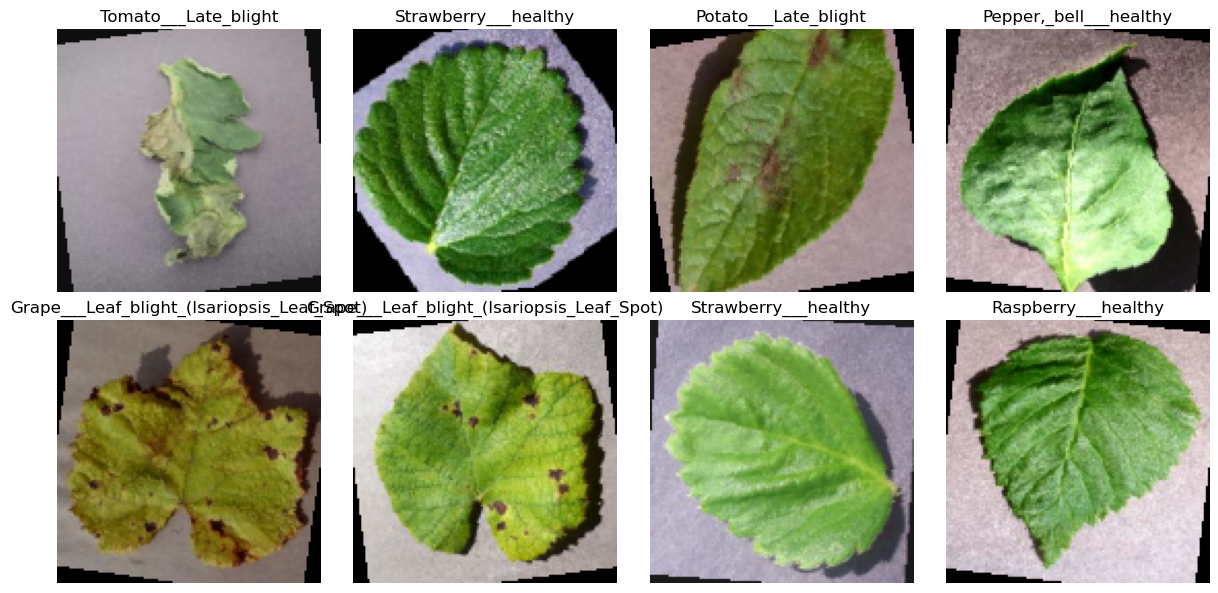

In [9]:
images, labels = next(iter(train_loader))

fig, ax = plt.subplots(2,4, figsize=(12,6))
for i in range(8):
    img = images[i].permute(1,2,0).numpy()
    img = (img * 0.5) + 0.5
    ax[i//4, i%4].imshow(img)
    ax[i//4, i%4].set_title(class_names[labels[i]])
    ax[i//4, i%4].axis("off")

plt.tight_layout()
plt.show()

# Custom CNN Architecture

Architecture:

    Conv → ReLU → Pool
        ↓
    Conv → ReLU → Pool
        ↓
    Flatten
        ↓
    Fully Connected
        ↓
    Classification

In [10]:
class PlantCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # ----------------------------------------
        # FEATURE EXTRACTION
        # ----------------------------------------

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64,128,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # ----------------------------------------
        # CLASSIFIER
        # ----------------------------------------

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512,num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
model = PlantCNN(num_classes)
model = model.to(device)

print(model)

PlantCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=38, bias=True)
  )
)


# Forward Pass Intuition

Early CNN layers learn:
- edges
- gradients
- color transitions

Middle layers learn:
- textures
- lesions
- spot structures

Deep layers learn:
- disease identity
- semantic pathology patterns

# Cross Entropy Loss

Measures:
difference between prediction distribution
and true class distribution.

In [12]:
criterion = nn.CrossEntropyLoss()

# Adam Optimizer

Adam combines:
- momentum
- adaptive learning rates

This accelerates convergence.

In [13]:
optimizer = optim.Adam(model.parameters(),lr=0.001)

# TRAINING LOOP
# THIS is the heart of deep learning.

train_losses = []
valid_losses = []

train_accuracies = []
valid_accuracies = []

# Train function
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # ------------------------------------
        # FORWARD
        # ------------------------------------

        outputs = model(images)
        loss = criterion(outputs, labels)

        # ------------------------------------
        # BACKPROP
        # ------------------------------------

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # ------------------------------------
        # METRICS
        # ------------------------------------

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [14]:
# validation function
def validate(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [15]:
EPOCHS = 10

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(model,train_loader)
    valid_loss, valid_acc = validate(model,valid_loader)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    train_accuracies.append(train_acc)
    valid_accuracies.append(valid_acc)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Train Accuracy: {train_acc:.4f}")

    print(f"Valid Loss: {valid_loss:.4f}")

    print(f"Valid Accuracy: {valid_acc:.4f}")


Epoch 1/10
Train Loss: 1.2101
Train Accuracy: 0.6384
Valid Loss: 0.5551
Valid Accuracy: 0.8214

Epoch 2/10
Train Loss: 0.5472
Train Accuracy: 0.8270
Valid Loss: 0.2964
Valid Accuracy: 0.9069

Epoch 3/10
Train Loss: 0.4060
Train Accuracy: 0.8701
Valid Loss: 0.2361
Valid Accuracy: 0.9251

Epoch 4/10
Train Loss: 0.3372
Train Accuracy: 0.8920
Valid Loss: 0.1974
Valid Accuracy: 0.9367

Epoch 5/10
Train Loss: 0.2897
Train Accuracy: 0.9072
Valid Loss: 0.1816
Valid Accuracy: 0.9415

Epoch 6/10
Train Loss: 0.2576
Train Accuracy: 0.9176
Valid Loss: 0.2020
Valid Accuracy: 0.9338

Epoch 7/10
Train Loss: 0.2280
Train Accuracy: 0.9263
Valid Loss: 0.1289
Valid Accuracy: 0.9570

Epoch 8/10
Train Loss: 0.2152
Train Accuracy: 0.9299
Valid Loss: 0.1291
Valid Accuracy: 0.9582

Epoch 9/10
Train Loss: 0.2001
Train Accuracy: 0.9351
Valid Loss: 0.1287
Valid Accuracy: 0.9567

Epoch 10/10
Train Loss: 0.1895
Train Accuracy: 0.9392
Valid Loss: 0.1127
Valid Accuracy: 0.9619


# Learning Curves

Analyze:
- convergence
- optimization
- overfitting

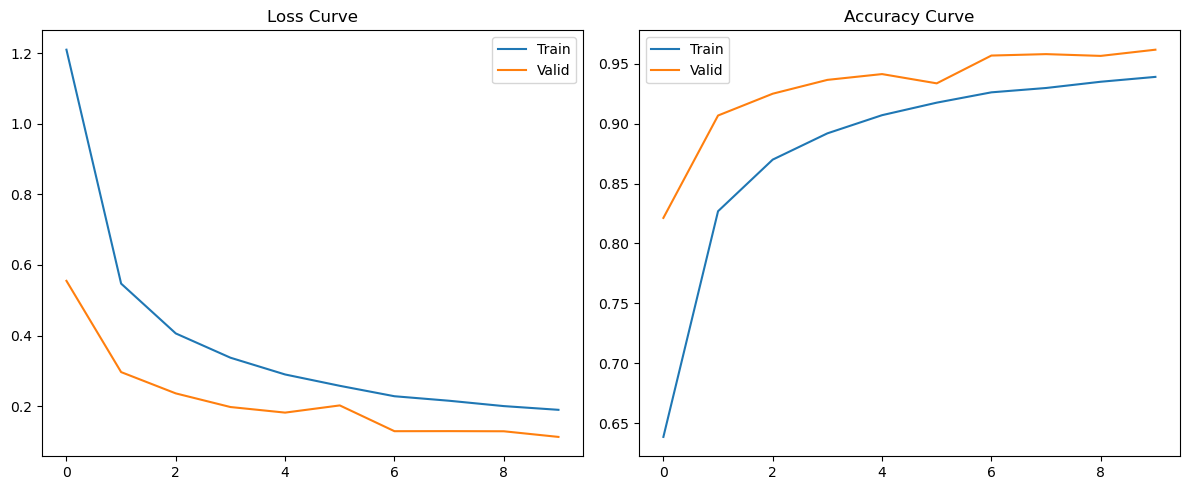

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train')
plt.plot(valid_losses, label='Valid')
plt.title("Loss Curve")
plt.legend()


plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train')
plt.plot(valid_accuracies, label='Valid')
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

# Confusion Matrix

Shows:
    - which diseases the model confuses.

In [17]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in valid_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

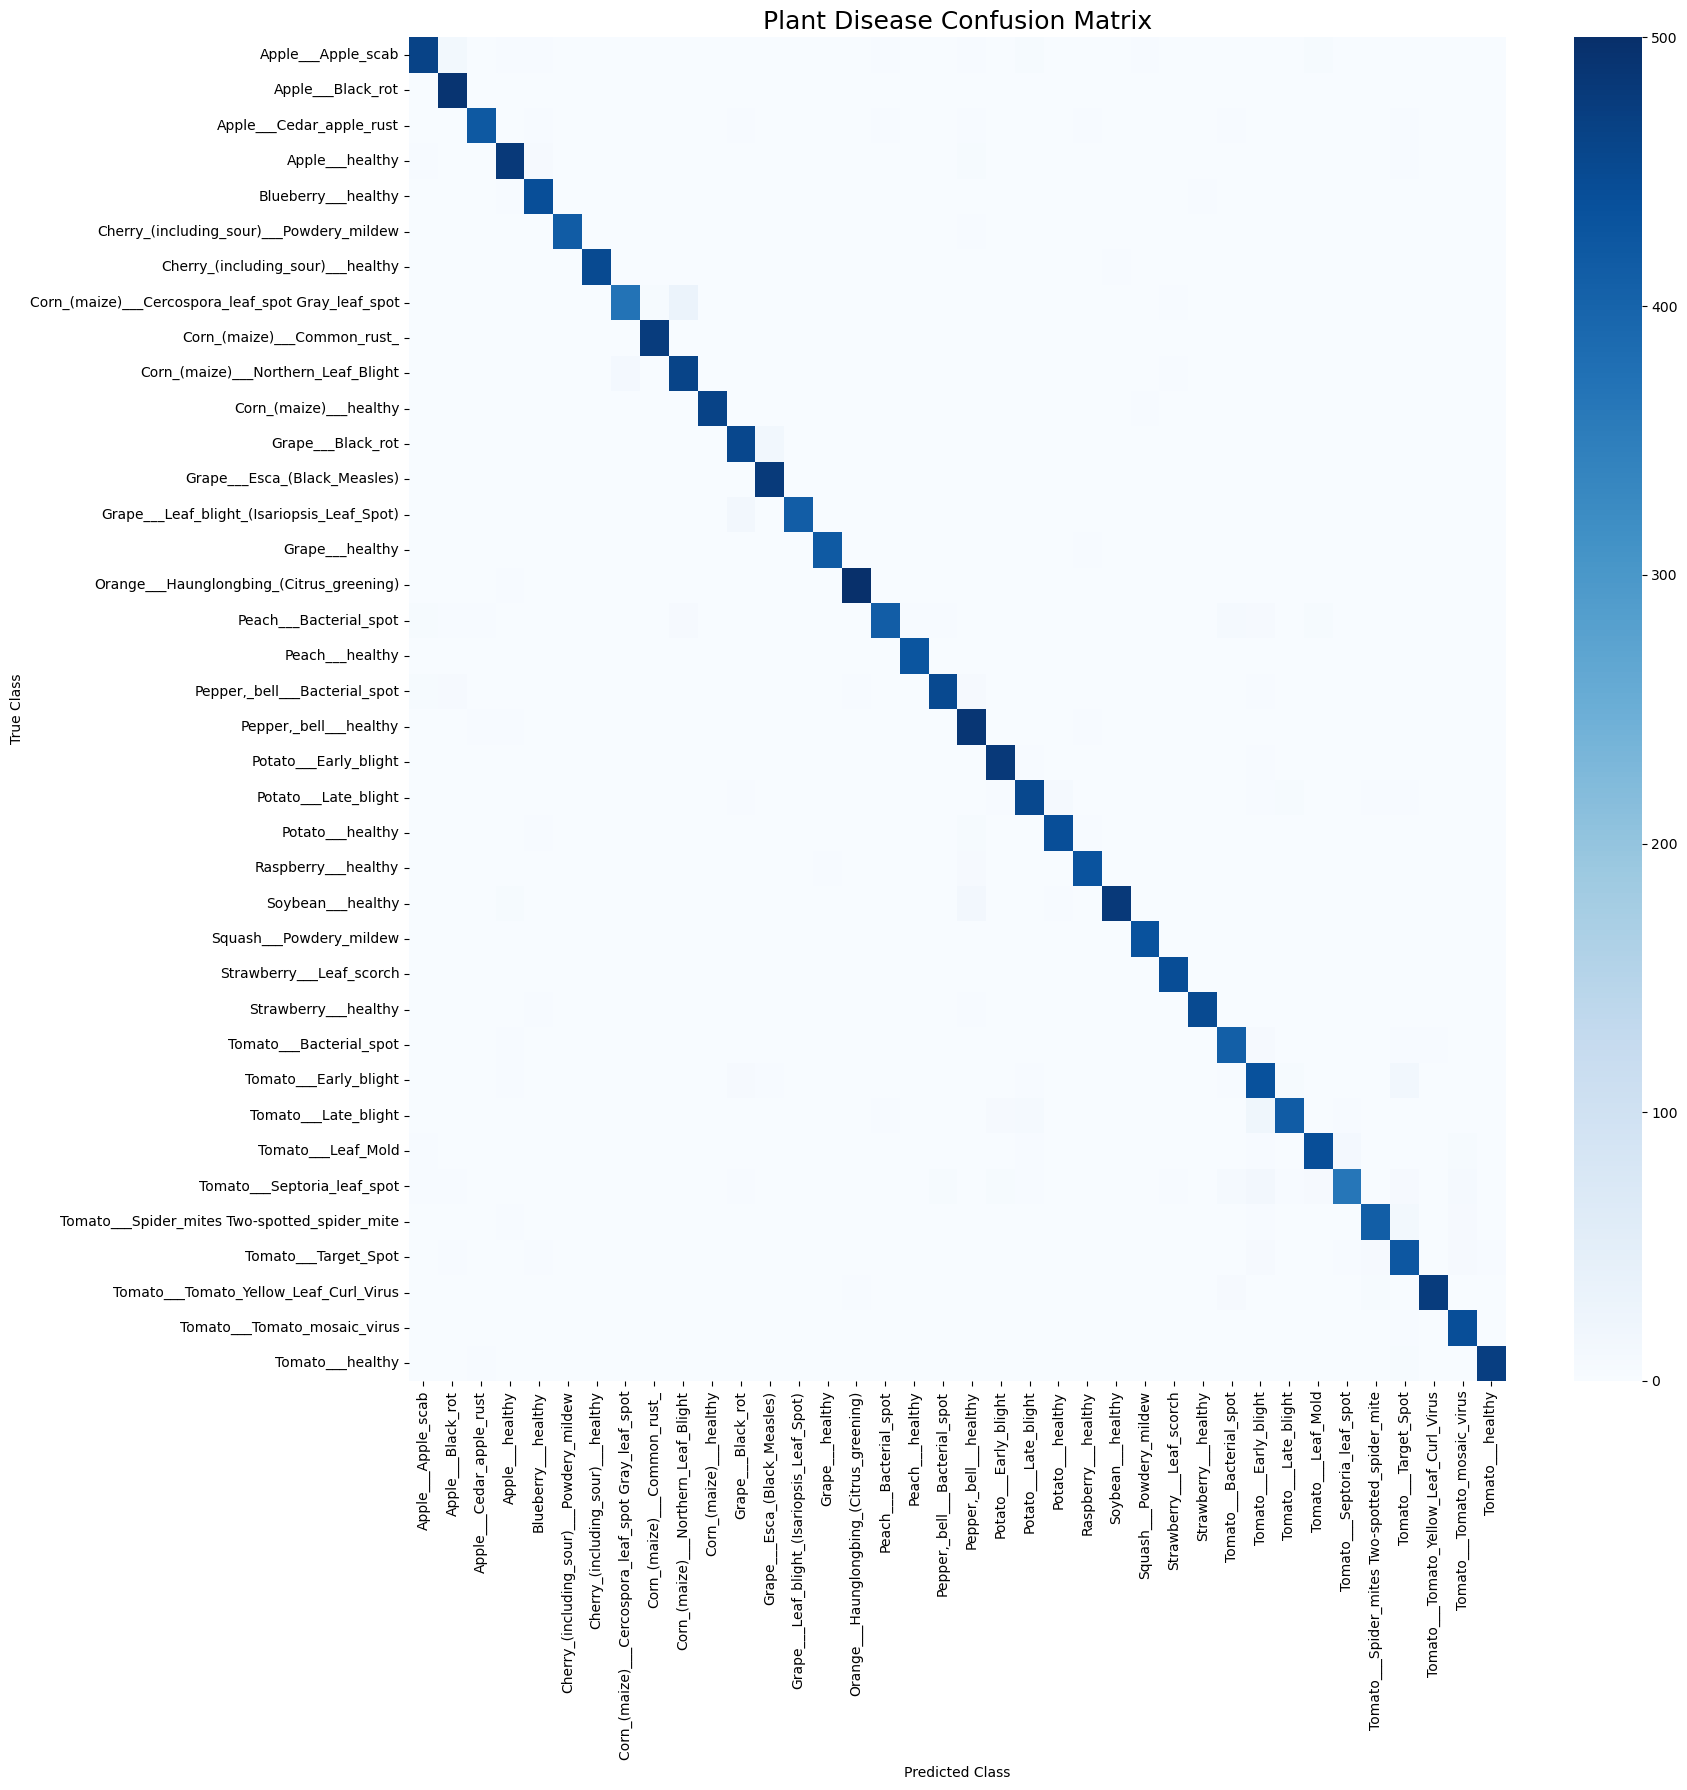

In [19]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(18,18))

sns.heatmap(
    cm,
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Plant Disease Confusion Matrix",
    fontsize=18
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## slight off-diagonal leakage.

Correct, Because:

    - perfect matrix can sometimes indicate:

            leakage
            bug
            overfitting

But yours has:

    tiny realistic confusion
    mostly healthy structure

So this looks believable.

In [20]:
print(classification_report(all_labels,all_preds,target_names=class_names))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.95      0.92      0.94       504
                                 Apple___Black_rot       0.95      0.99      0.97       497
                          Apple___Cedar_apple_rust       0.98      0.96      0.97       440
                                   Apple___healthy       0.95      0.96      0.95       502
                               Blueberry___healthy       0.95      0.98      0.96       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      0.99       421
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.97      0.90      0.93       410
                       Corn_(maize)___Common_rust_       0.99      1.00      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.92      0.97      0.

# Failure Analysis

Even high-performing CNNs fail.

Common reasons include:

- visually similar diseases
- illumination changes
- texture overlap
- class imbalance
- background bias

Understanding failure cases is essential for:
- model robustness
- explainability
- real-world deployment

In [23]:
# STEP 1 — FIND MISCLASSIFIED IMAGES
# ============================================================
# FIND MISCLASSIFIED SAMPLES
# ============================================================

misclassified_images = []
misclassified_labels = []
misclassified_preds = []

model.eval()

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        # ----------------------------------------------------
        # FIND WRONG PREDICTIONS
        # ----------------------------------------------------

        wrong_mask = preds != labels
        wrong_images = images[wrong_mask]
        wrong_labels = labels[wrong_mask]
        wrong_preds = preds[wrong_mask]

        misclassified_images.extend(wrong_images.cpu())
        misclassified_labels.extend(wrong_labels.cpu())
        misclassified_preds.extend(wrong_preds.cpu())

We isolate:

    CNN failure samples.

This becomes:

    visual debugging.

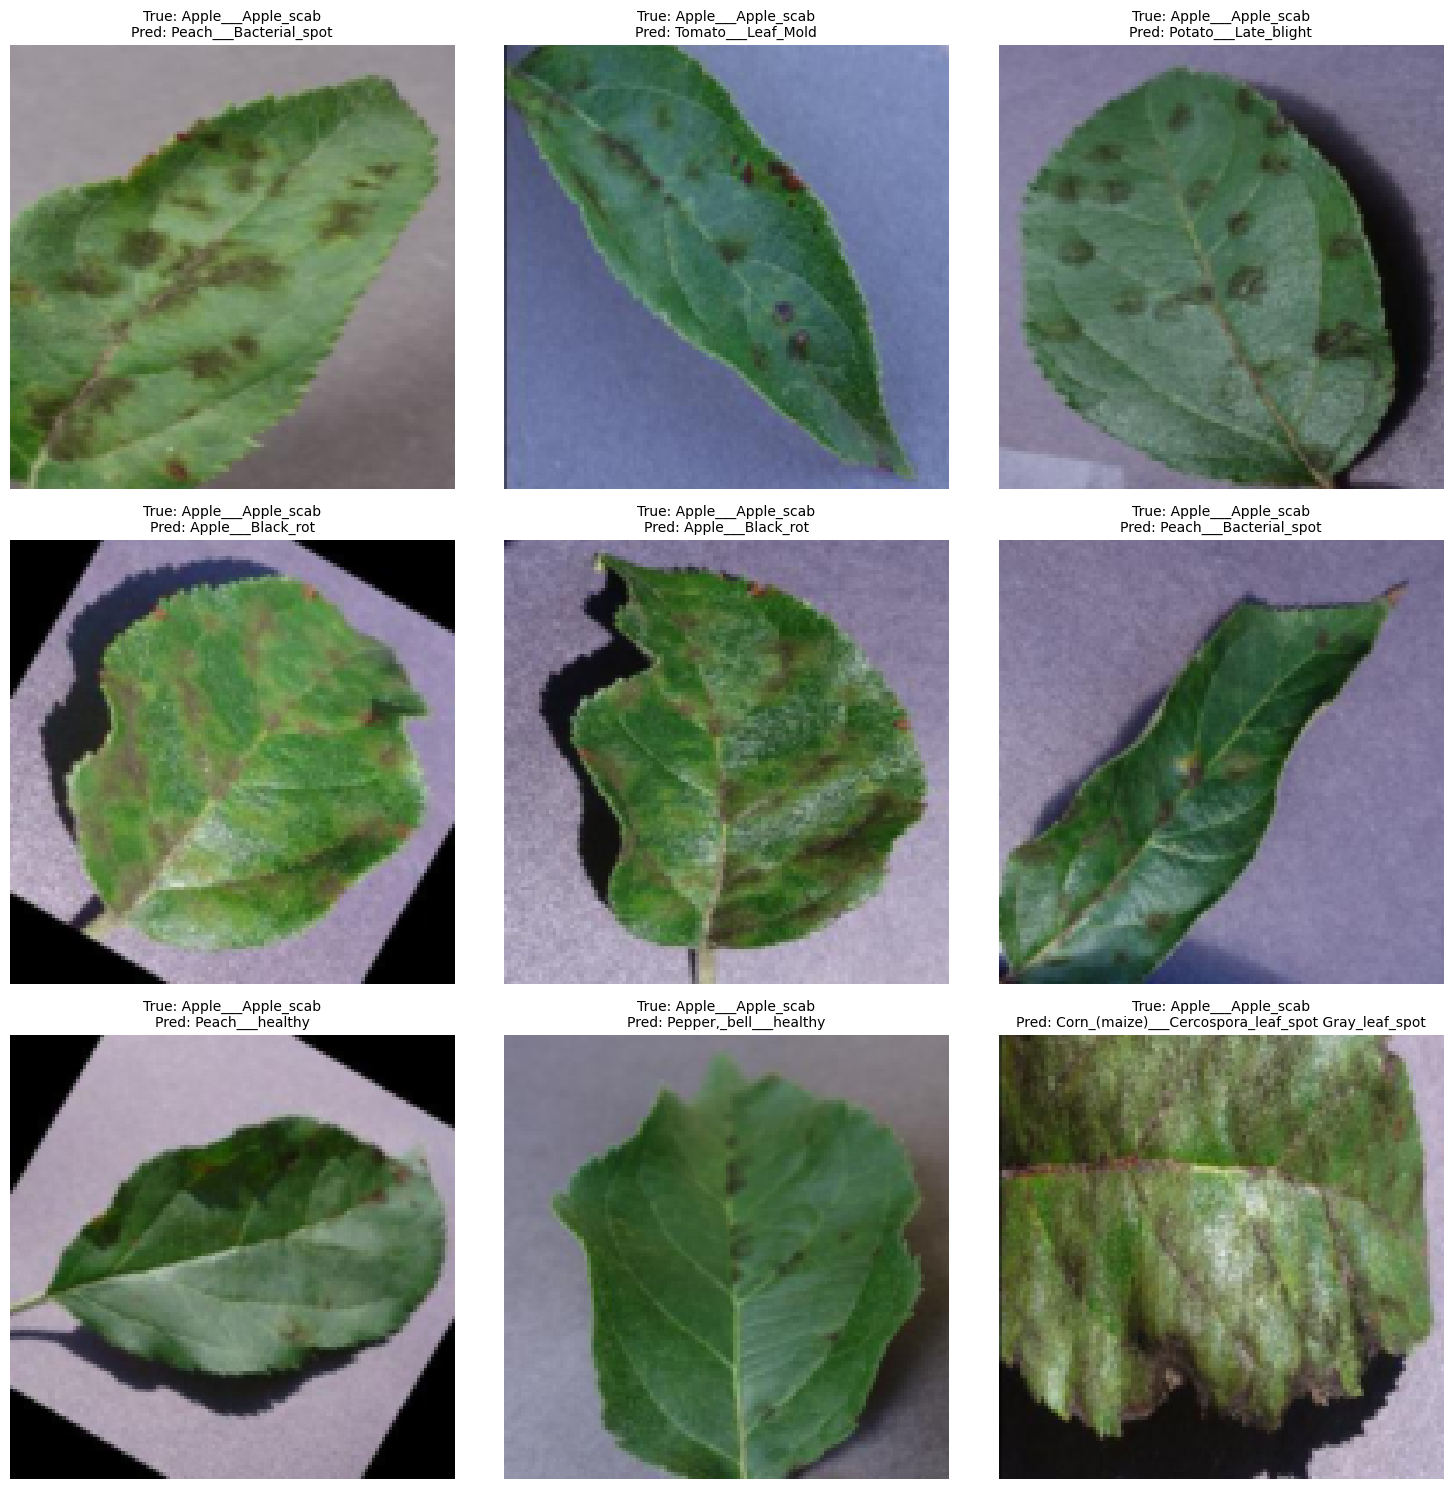

In [24]:
# STEP 2 — VISUALIZE FAILURES

# ============================================================
# VISUALIZE MISCLASSIFICATIONS
# ============================================================

num_samples = min(9, len(misclassified_images))
plt.figure(figsize=(15,15))

for i in range(num_samples):

    img = misclassified_images[i]
    true_label = class_names[
        misclassified_labels[i]
    ]
    pred_label = class_names[
        misclassified_preds[i]
    ]

    # --------------------------------------------
    # TENSOR → IMAGE
    # --------------------------------------------

    img = img.permute(1,2,0).numpy()
    img = (img * 0.5) + 0.5
    img = np.clip(img, 0, 1)
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(
        f"True: {true_label}\nPred: {pred_label}",
        fontsize=10
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## observing:

this is CNN confusion behavior.

    model interpretability
    debugging intelligence
    engineering maturity

# STEP 3 — ANALYZE FAILURE PATTERNS

# Failure Pattern Analysis

Observed CNN failure modes include:

1. Similar Disease Appearance
2. Small Lesions
3. Lighting Variation
4. Background Confusion
5. Texture Similarity
6. Early Disease Stages

These failures reveal limitations in:
- feature separability
- generalization
- visual robustness

# STEP 4 — LIGHTING VARIATION EXPERIMENT
VERY strong for presentation

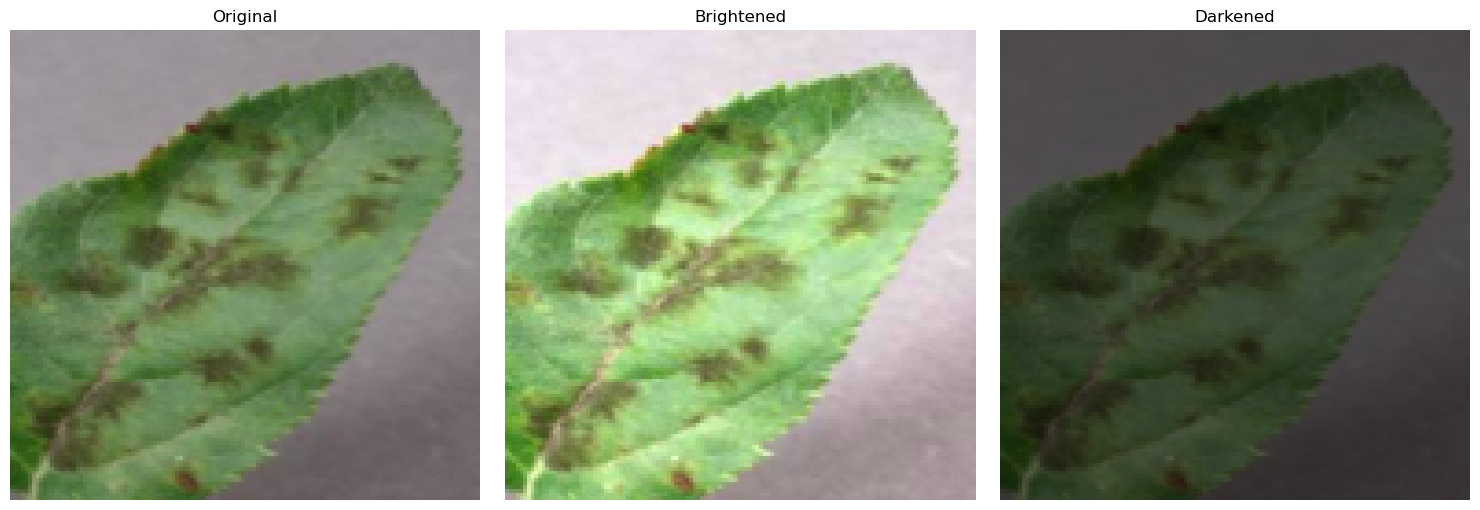

In [25]:
# ============================================================
# LIGHTING VARIATION TEST
# ============================================================

sample_img = misclassified_images[0]
sample_img = sample_img.permute(1,2,0).numpy()
sample_img = (sample_img * 0.5) + 0.5
sample_img = np.clip(sample_img, 0, 1)

# ------------------------------------------------------------
# BRIGHTER
# ------------------------------------------------------------

bright = np.clip(sample_img * 1.5,0,1)

# ------------------------------------------------------------
# DARKER
# ------------------------------------------------------------

dark = np.clip(sample_img * 0.5,0,1)

# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(sample_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(bright)
plt.title("Brightened")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(dark)
plt.title("Darkened")
plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
# STEP 5 — CLASS CONFUSION ANALYSIS

# ============================================================
# MOST CONFUSED CLASS PAIRS
# ============================================================

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

max_idx = np.unravel_index(
    np.argmax(cm_no_diag),
    cm_no_diag.shape
)

true_class = class_names[max_idx[0]]
pred_class = class_names[max_idx[1]]

print("Most Confused Pair:")
print(f"True Class: {true_class}")
print(f"Predicted As: {pred_class}")

Most Confused Pair:
True Class: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Predicted As: Corn_(maize)___Northern_Leaf_Blight


now identify:

    which diseases visually overlap most.

This becomes: <span style="color:pink; font-size:18px">actual pathology analysis.</span>

# SECTION 17 — OVERFITTING ANALYSIS

This is one of the MOST important deep learning concepts.

# Overfitting Analysis

Overfitting occurs when:
the CNN memorizes training data
instead of learning generalizable patterns.

Symptoms include:
- very high training accuracy
- lower validation accuracy
- unstable validation loss

This is one of the biggest challenges in deep learning.

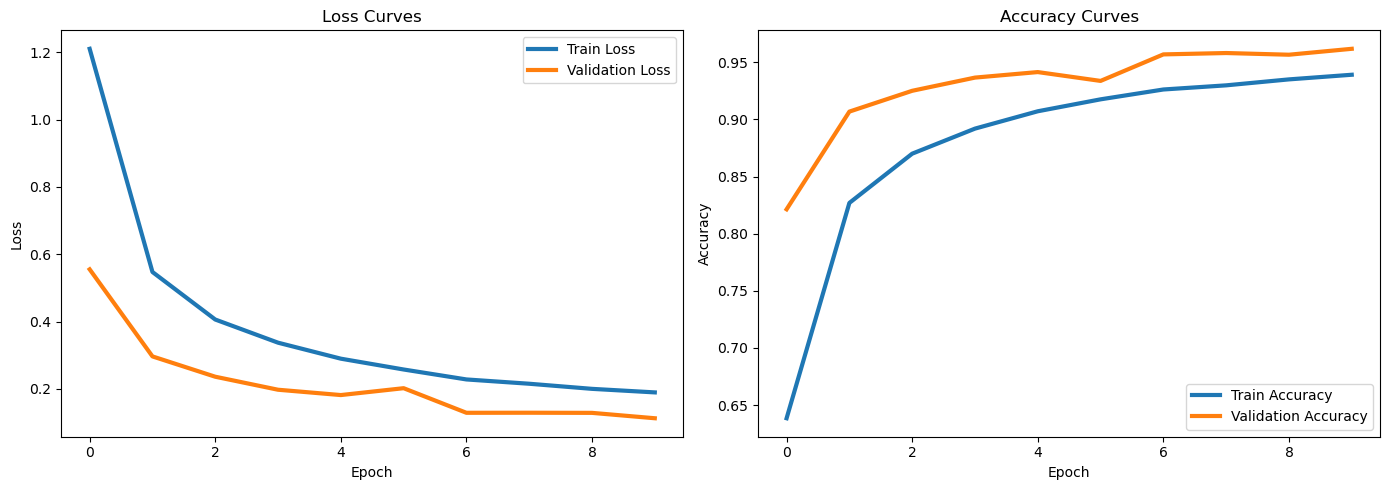

In [28]:
# STEP 1 — VISUALIZE LEARNING CURVES

plt.figure(figsize=(14,5))

# ------------------------------------------------------------
# LOSS
# ------------------------------------------------------------

plt.subplot(1,2,1)
plt.plot(train_losses,label='Train Loss',linewidth=3)
plt.plot(valid_losses,label='Validation Loss',linewidth=3)
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# ------------------------------------------------------------
# ACCURACY
# ------------------------------------------------------------

plt.subplot(1,2,2)
plt.plot(train_accuracies,label='Train Accuracy',linewidth=3)
plt.plot(valid_accuracies,label='Validation Accuracy',linewidth=3)
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## GOOD GENERALIZATION
```train accuracy ≈ validation accuracy```

## OVERFITTING
```train accuracy ↑↑↑
validation accuracy stagnates
```
OR

```validation loss increases```

In [29]:
# STEP 2 — AUTOMATIC OVERFITTING DETECTION

final_train_acc = train_accuracies[-1]
final_valid_acc = valid_accuracies[-1]
gap = final_train_acc - final_valid_acc

print(f"Train Accuracy: {final_train_acc:.4f}")
print(f"Validation Accuracy: {final_valid_acc:.4f}")
print(f"Generalization Gap: {gap:.4f}")

Train Accuracy: 0.9392
Validation Accuracy: 0.9619
Generalization Gap: -0.0227


## 🔥 INTERPRETATION

| Gap       | Meaning            |
| --------- | ------------------ |
| < 0.03    | excellent          |
| 0.03–0.08 | manageable         |
| > 0.10    | strong overfitting |


# STEP 3 — OVERFITTING EXPLANATION

### Why Overfitting Happens

CNNs contain millions of parameters.

Large networks can memorize:
- textures
- lighting
- backgrounds
- dataset artifacts

instead of learning:
- robust disease semantics.

This becomes especially dangerous in:
- small datasets
- clean datasets
- highly repetitive datasets

# 🚀 STEP 4 — MITIGATION STRATEGIES

## Overfitting Mitigation

Several techniques help improve generalization:

## 1. Data Augmentation
Introduces visual variability.

## 2. Dropout
Randomly disables neurons during training.

## 3. Weight Regularization
Penalizes large weights.

## 4. Early Stopping
Stops training before memorization.

## 5. Batch Normalization
Stabilizes activations and gradients.

## 6. More Diverse Data
Improves robustness.

# STEP 5 — EARLY STOPPING LOGIC
```
best_valid_loss = float('inf')

patience = 3
counter = 0
```

## INSIDE TRAINING LOOP
```
if valid_loss < best_valid_loss:
    best_valid_loss = valid_loss
    counter = 0
else:
    counter += 1

if counter >= patience:
    print("Early stopping triggered.")
    break
```

Training too long:

    memorizes noise
    hurts generalization

Early stopping:

    preserves robustness.

# 🚀 FINAL SECTION — ENGINEERING INSIGHT

### CNN Engineering Insights

This notebook demonstrated:

- feature hierarchy learning
- optimization dynamics
- convolutional abstraction
- gradient-based learning
- model generalization
- failure analysis

The CNN gradually learned:
- edges
- textures
- lesion patterns
- disease semantics

This forms the foundation for:
- transfer learning
- edge optimization
- quantization
- deployment

Understanding WHY CNNs fail
is just as important as understanding
why they succeed.

| Advanced Topic             | Present |
| -------------------------- | ------- |
| confusion matrix           | ✅       |
| misclassification analysis | ✅       |
| lighting robustness        | ✅       |
| class confusion analysis   | ✅       |
| overfitting analysis       | ✅       |
| generalization gap         | ✅       |
| mitigation strategies      | ✅       |
| early stopping             | ✅       |


In [34]:
# save the trained model
import os

cwd = os.getcwd()
if os.path.basename(cwd) == "notebooks":
	BASE_ADDR = os.path.abspath(os.path.join(cwd, ".."))
else:
	BASE_ADDR = os.path.abspath(cwd)

MODEL_PATH = os.path.join(BASE_ADDR, "models", "plant_cnn.pth")


In [ ]:
params_million = sum(p.numel() for p in model.parameters()) / 1e6
params_million

# this is needed in 05_mobilenet_transfer_learning.ipynb — we will be using a pretrained MobileNetV2 model, 
# and it's helpful to know how many parameters our custom CNN has for comparison. 
# MobileNetV2 is a much larger model, and it will have many more parameters than our small custom CNN.
# By calculating the number of parameters in our model, we can get a sense of its capacity and compare it to the pretrained MobileNetV2,
# which has around 3.4 million parameters. 

# This helps us understand the difference in model complexity and why transfer learning with a larger model
#  might yield better results on our plant disease classification task.

# torch numel is the total number of elements in a tensor. For example, if you have a tensor of shape (3,4), it has 12 elements, 
# so numel() would return 12. In the context of model parameters, it gives you the total number of parameters in the model.
# and params_million is just the total number of parameters in the model divided by 1 million, 
# which is a common way to express model size in a more human-readable format.

16.89047

In [45]:
for name, param in model.named_parameters():
    print(
        f"{name:40} "
        f"{param.numel()/1e6:.4f} M"
    )

features.0.weight                        0.0009 M
features.0.bias                          0.0000 M
features.3.weight                        0.0184 M
features.3.bias                          0.0001 M
features.6.weight                        0.0737 M
features.6.bias                          0.0001 M
classifier.1.weight                      16.7772 M
classifier.1.bias                        0.0005 M
classifier.4.weight                      0.0195 M
classifier.4.bias                        0.0000 M
